# 2. Handling Spatial Data in R

## 2.1 Overview

The aim of this section is to provide an introduction to the mapping and geographical data handling capabilities of R. It focuses mostly on developing the building blocks for spatial data analyses in later sections. These sections will extend the mapping functionality that was briefly introduced in the previous section and will be further extended into section 5. It includes an introduction to the `GISTools` package and its functions, describing the methods used for producing choropleth maps - from basic to advanced outputs- and introduces some methods for generating descriptive statistics. These skills are important to the analyses that will be developed later in this website. This section will:

- Introduce the `GISTools` package.
- describe how to compile maps based on multiple layers.
- Describe how to set different shading schemes.
- Describe how to plot spatial data with different parameters.
- Describe how to develop basic descriptive statistical analyeses of spatial data.

## 2.2 Introduction: `GISTools`

The previous section introduced some basic analytical and graphical techniques using R. however, only a few of those were geographical. A number of packages are available in R that allow complex visualisation, manipulation, and analysis of spatial data. Some of this functinality will be demonstated in this section alongside some mapping tools and specific data types to create different exampls of mapping in R. Remember that a package in R is a set of pre-written functions that are not available when you initially start R, but can be loaded from the R library at the command line. To show you these techniques, I will start by developing some elementary maps, building to more sophisticated mapping.

### 2.2.1 Installing and Loading `GISTools`

You will use dfferent methods and tools contained within the `GISTools` package to draw maps and to handle spatial information. You should have installed `GISTools` onto your computer as you ran the code in Section 1 using the `install.packages` cmmand. Once you have downloaded and installed the package on your computer, you can simply load the package when you use R subsequently. to load `GISTools` into the R ession that you have just started, simply enter:

In [ ]:
library(GISTools)

It is possible to inspect the functionality and tools available in `GISTools` or any other package by examining the documentation:

In [ ]:
help(GISTools)

or

In [ ]:
?GISTools

This provides a general description of the package. At the bottom of the help window, there is a hyperlink to the index which, if you click on it, will open a page with a list of all the tools available in the package.

### 2.2.2 Spatial Data in `GISTools`

`GISTools`, just like many other R packages, come with a number of embedded datasets that can be loaded from the command line after the package is installed. Two datasets will be used in this section: polygon and line data for **New Haven**, **Connecticut**, and **Counties**, all cities in the USA. Unfortunately, just like many packages used in this site that have embedded datasets, the datasets will not cover all regions and your region of interest.

The first thing you should do with any dataset is to examine it. For spatial data, this often means that a visual examination of its spatial properties and maybe a more formal consideration of its attributes. Initially you will use the New Haven fatasets to draw your first map in R. Load the New Haven data:

In [2]:
data(newhaven)

To examine the data that has been loaded, enter:

In [3]:
ls()

[1] "blocks"          "breach"          "burgres.f"       "burgres.n"      
 [5] "city_points"     "colors"          "famdisp"         "places"         
 [9] "pop_data"        "province_colors" "province_pop"    "provinces"      
[13] "provinces_pop"   "roads"           "tracts"

This prints out all the datasets that are loaded for **New Haven**. A number of these, including the data called *roads*, are geographical data. Enter:

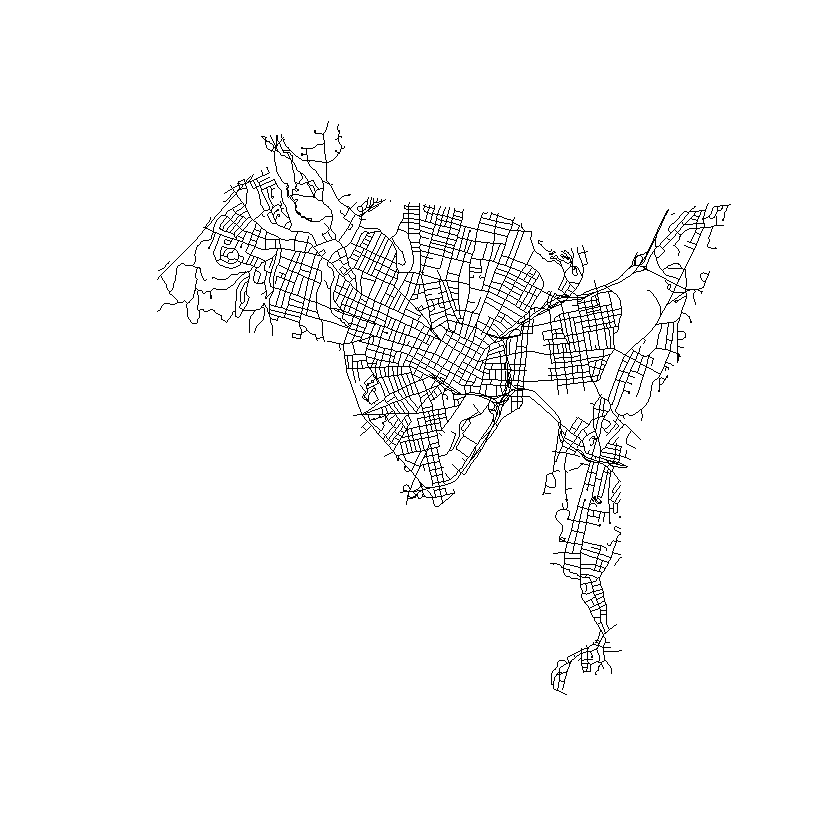

In [4]:
plot(roads)

and a map of the roads in New Haven will appear. 

To determine the class of the roads dataset, enter:

In [5]:
class(roads)

[1] "SpatialLinesDataFrame"
attr(,"package")
[1] "sp"

This shows that roads is a variable of class **SpatialLinesDataFrame**, defined in the `sp` package that was automatically loaded in with `GISTools`. You should investigate the class of *blocks*, *tracts*, and *breach* in the same way. The `sp` package defines a number of classes as summarised in the table below.

| Names             | With attributes          | ArcGIS Equivalent |
| :---------------- | :----------------------: | :-----------------|
| SpatialPoints     | SpatialPointDataFrame    | Point shapefiles  |
| SpatialLines      | SpatialLinesDataFrame    | Line shapefiles   |
| SpatialPoints     | SpatialPolygonsDataFrame | Polygon shapefile |

So, for example, the *breach* data are a `SpatialPoints` class that simply describes the locations, with no atributes, whereas the *blocks* data are of the `SpatialPolygonsDataFrame` class as they include some census variable associated with each census block. Thus spatial data with attributes defined in this way hold their attributes in the `data.frame` and you can see this by looking at the first few lines of the *blocks* `data.frame` using the `head` function.

In [6]:
head(data.frame(blocks))

,NEWH075H_,NEWH075H_I,HSE_UNITS,OCCUPIED,VACANT,P_VACANT,P_OWNEROCC,P_RENTROCC,NEWH075P_,NEWH075P_I,⋯,P_UNDER5,P_5_13,P_14_17,P_18_24,P_25_34,P_35_44,P_45_54,P_55_64,P_65_74,P_75_UP
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,2,69,763,725,38,4.980341,0.393185,94.626474,2,380,⋯,12.813022,24.707846,7.888147,12.479132,16.026711,8.555927,5.759599,4.924875,4.048414,2.796327
1,3,72,510,480,30,5.882353,20.392157,73.725490,3,385,⋯,1.921198,2.474764,0.814067,71.149463,7.359166,4.037773,1.595571,1.758385,3.712146,5.177467
2,4,64,389,362,27,6.940874,57.840617,35.218509,4,394,⋯,10.441767,13.554217,5.722892,8.835341,17.670683,17.871486,8.734940,5.923695,7.931727,3.313253
3,5,68,429,397,32,7.459207,19.813520,72.727273,5,399,⋯,10.853293,17.739521,7.709581,12.425150,18.113772,10.853293,9.056886,6.287425,4.266467,2.694611
4,6,67,443,385,58,13.092551,80.361174,6.546275,6,404,⋯,6.229508,8.633880,2.950820,7.103825,17.267760,16.830601,8.415301,7.431694,14.426230,10.710383
5,7,133,588,548,40,6.802721,52.551020,40.646259,7,406,⋯,8.725341,8.194234,3.641882,10.091047,29.286798,12.898331,7.814871,7.814871,6.904401,4.628225


This printed out the first six rows of attributes associated with the census *blocks* data. A formal consideration of spatial attributes and how to analyse and map them is given later in this section. The census *blocks* in **New Haven** can be plotted:

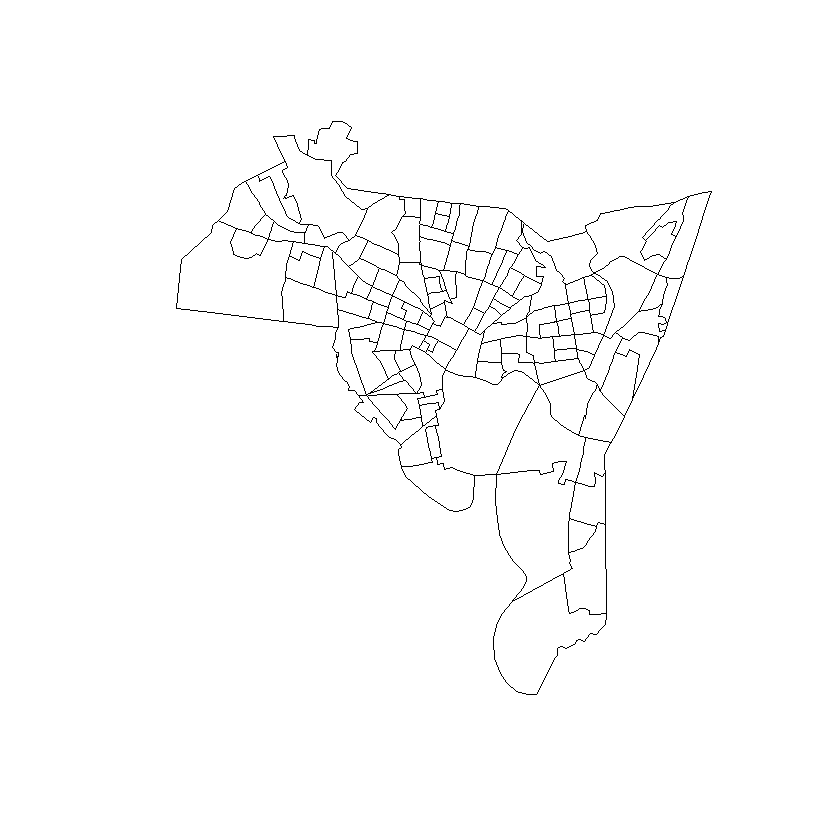

In [7]:
plot(blocks)

Now suppose we want to plot another variable with the census *blocks* which shows the roads for the area. Entering:

`plot(blocks)`

will draw a map of the roads. However, one problem is that this has now overwritten the blocks that were drawn before. to stop this from happening, an extra parameter called `add` can be included in the second plot to call to ensure that the first set of data that was plotted is not overwritten. This overlays (rather than overwrite) the information. The `add=TRUE` part sets a parameter in the `plot` command to the logical value `TRUE`, insructing R not to overwrite, but to add the new information to the existing plot. A number of other parameters can also be included. For example, enter: 

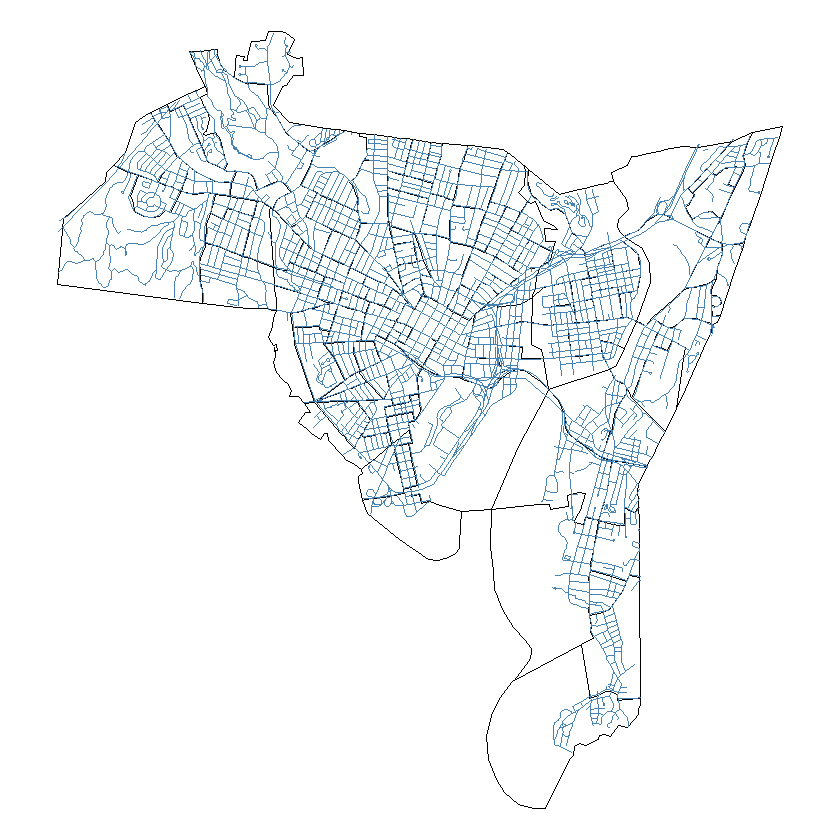

In [8]:
par(mar = c(0, 0, 0, 0))
plot(blocks)
plot(roads, add=TRUE, col = "steelblue")

The first line plots the *blocks* data. Again, because there are no other parameters, this starts a new plot. The next line adds the *roads* data, but the extra parameter tells R to draw them in `steelblue` colour. Note that where quotes are needed these can be either single or double quotes, but not mixed and not formatted into curly quotes. Your map should look like the one above.

The `plot` commands above generate maps of the census *blocks* and the *roads* in **New Haven**, regardless of whether the data describes area or linear features. Those familiar with GIS will recognise these as two of the commonly referred to vector features often cited in a GIS context of "points, lines, and areas". In R, the command `plot` can also be used to plot point features. For example:

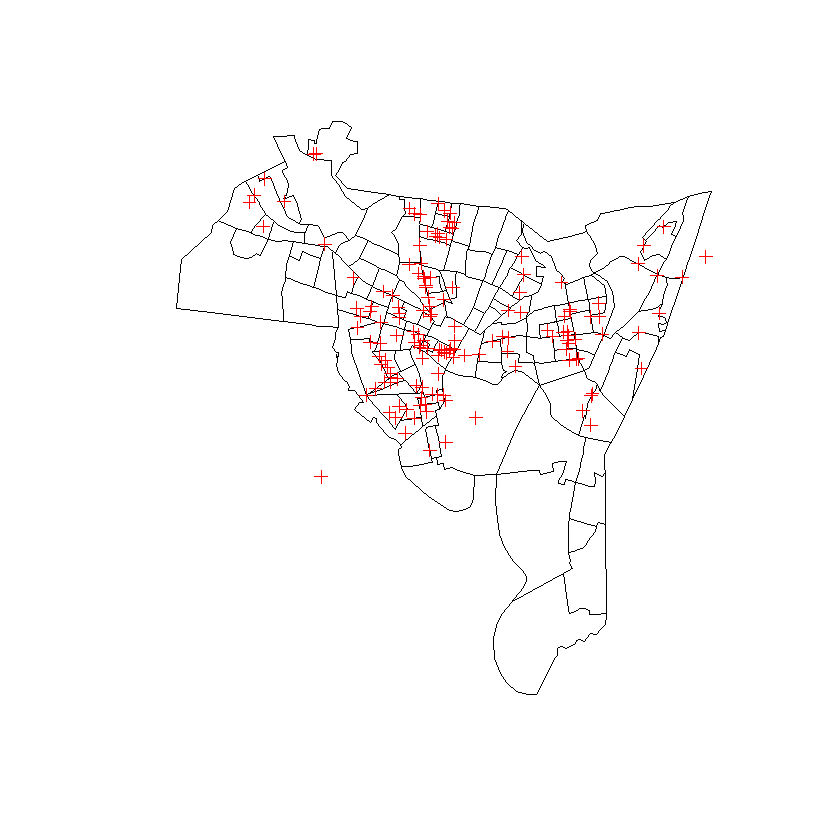

In [9]:
plot(blocks)
plot(breach, add=TRUE, col="red")

This draws a map of loactions where breaches of the pece have occured in **New Haven**, overlaying the census *blocks*. Note that thedefault plot character is a cross and that some aras have a greater density of incidents that others. Remember from Section 1 that `pch` can be used to change the plot character for graphs. It can be used in the same way to map point spatial data. You should experiment with different `pch` and colour settings to get the best visualisations of the *breaches* of the peace and the census *blocks* data together. For example:

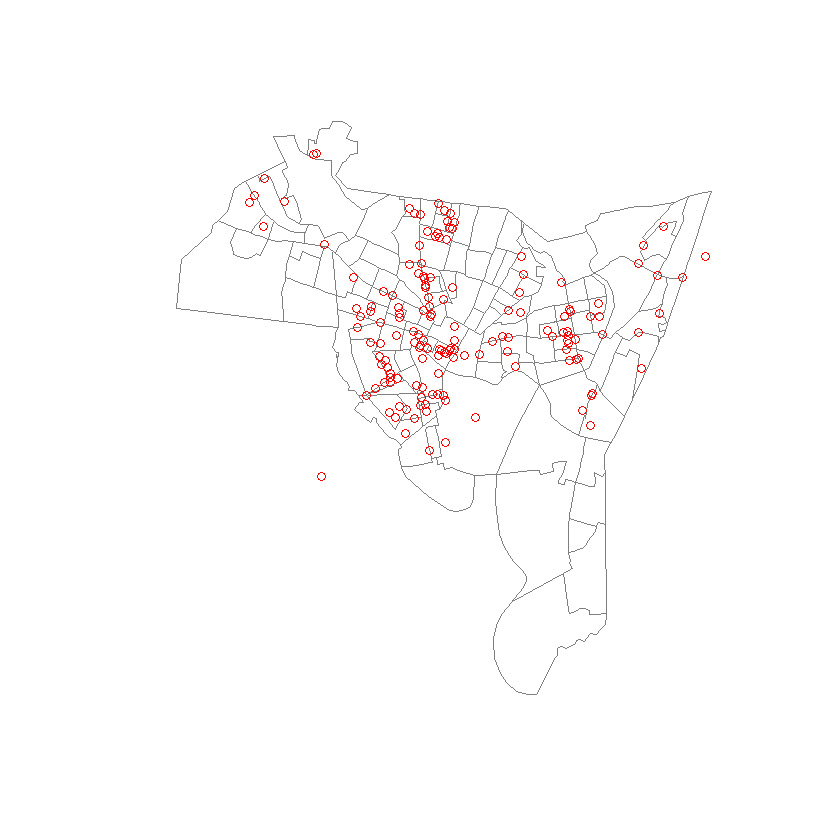

In [10]:
plot(blocks, lwd = 0.5, border = "grey50")
plot(breach, col = "red", pch = 1, add = TRUE)

If you are uncertain of the available colours in R, you can display a list of colours by entering:

In [ ]:
colors()

And remember that help for `plot` describes many plot options, including different plot characters.